In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [8]:
def pkpc_h_to_cmpc_h(z):
    return (1+z)/1e3

In [9]:
z0=1.5

In [324]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw

cosmo = cosmology.setCosmology('planck15')
p_nfw0 = profile_nfw.NFWProfile(M = 1E13, c = 3
                               , z = z0, mdef = 'vir')

In [325]:
rho0_pkpc = p_nfw0.par['rhos']
rs_pkpc = p_nfw0.par['rs']
print(rho0_pkpc)
print(rs_pkpc)


3613435.6678519095
70.2107983709715


In [320]:
rs_cmpc_h = rs_pkpc*pkpc_h_to_cmpc_h(z0)
rho0_cmpc_h = rho0_pkpc / pkpc_h_to_cmpc_h(z0)**3

In [246]:
Rmax_ckpc = 100

In [247]:
p_nfw = profile_nfw.NFWProfile(rhos=rho0_pkpc, rs=rs_pkpc)

In [248]:
r1 = np.linspace(1e-3, Rmax_ckpc*(1+z0), 10000)
rho_nfw = p_nfw.density(r1)

In [249]:
from scipy import integrate

result = integrate.trapezoid((4*np.pi*r1**2)*p_nfw.density(r1), r1)
print(result)

249005343081.7585


In [257]:
result = 4*np.pi*integrate.trapezoid((r_vals_cmpc_h**2 * rho_values_cmpc_h * np.sin(k * r_vals_cmpc_h) / (k * r_vals_cmpc_h)) , r_vals_cmpc_h)
print(result)

1.0198036492949151e+27


In [250]:
dr = r1[1]-r1[0]
np.log10(4*np.pi*np.sum((r1**2 * rho_nfw * dr)))

11.396217167027375

In [251]:
encl_mass = p_nfw.enclosedMass(r1[-1])
print(encl_mass)

249005409746.2797


In [252]:
np.log10(encl_mass)

11.396208782426807

In [321]:
M = 4 * np.pi * rho0_cmpc_h * rs_cmpc_h**3
print(np.log10(M))

13.138884183660295


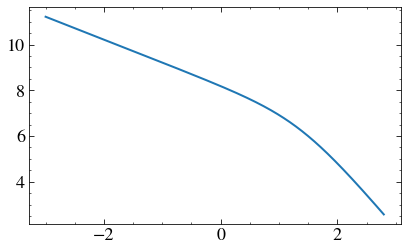

In [46]:
plt.plot(np.log10(r1), np.log10(rho_nfw))

In [47]:
def pkpc_h_to_cmpc_h(z):
    return (1+z)/1e3

In [48]:
def fourier_transform(k_values):
    ft_values = np.zeros_like(k_values)
    
    nbins = 10000
    r_vals_pkpc = np.linspace(1e-3, Rmax_ckpc*(1+z0), nbins)
    r_vals_cmpc = (1+z0) * r_vals_pkpc/1e3
    
    rho_values_pkpc = p_nfw.density(r_vals_pkpc)
    
    
    rho_values_cmpc = rho_values_pkpc * (1e3/(1+z0))**3
    
    rho_values = rho_values_cmpc
    r_values = r_vals_cmpc
    dr = r_values[1] - r_values[0]
    for i, k in enumerate(k_values):
        integral = 4*np.pi*np.sum((r_values**2 * rho_values * np.sin(k * r_values) / (k * r_values)) * dr)
        ft_values[i] = integral 
        
    norm_factor = 4*np.pi*np.sum((r_values**2 * rho_values *dr))
    print(norm_factor)
    print(np.log10(norm_factor))
    
    
    
    return ft_values/norm_factor

In [49]:
logks = np.arange(-1.5,1.5,0.001)
ks = 10**logks

2863100655282.1426
12.456836616364313


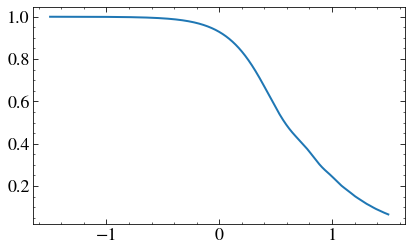

In [50]:
plt.plot(logks, fourier_transform(ks))

In [25]:
print(np.log10(encl_mass))

12.420830996552564


In [51]:
ftc4 = fourier_transform(ks)

2863100655282.1426
12.456836616364313


In [26]:
ftc5 = fourier_transform(ks)

2635353922013.53
12.420838948222505


In [115]:
ft11 = fourier_transform(ks)

265179668158.43097
11.423540222805515


In [98]:
ft13 = fourier_transform(ks)

30478778923124.2
13.483997563797095


In [70]:
ft12 = fourier_transform(ks)

2863100655282.1426
12.456836616364313


In [295]:
def u_from_rho(k_values, rho0_pkpc_h, rs_pkpc_h, Rmax_ckpc, z0=1.5):
    ft_values = np.zeros_like(k_values)
    p_nfw = profile_nfw.NFWProfile(rhos=rho0_pkpc_h, rs=rs_pkpc_h)
    
    
    nbins = int(1e2)
    r_vals_pkpc_h = np.linspace(1e-3, Rmax_ckpc*(1+z0), nbins)
    rho_values_pkpc_h = p_nfw.density(r_vals_pkpc_h)
    
    r_vals_cmpc_h = r_vals_pkpc_h * pkpc_h_to_cmpc_h(z0)
    rho_values_cmpc_h = rho_values_pkpc_h / (pkpc_h_to_cmpc_h(z0)**3)
    
    dr = r_vals_cmpc_h[1] - r_vals_cmpc_h[0]
    for i, k in enumerate(k_values):
        #integral = 4*np.pi*np.sum((r_vals_cmpc_h**2 * rho_values_cmpc_h * np.sin(k * r_vals_cmpc_h) / (k * r_vals_cmpc_h)) * dr)
        integral = 4*np.pi*integrate.trapezoid((r_vals_cmpc_h**2 * rho_values_cmpc_h * np.sin(k * r_vals_cmpc_h) / (k * r_vals_cmpc_h)) , r_vals_cmpc_h)
        ft_values[i] = integral 
    #print(integral)   
    #norm_factor = 4*np.pi*np.sum((r_vals_cmpc_h**2 * rho_values_cmpc_h *dr))
    norm_factor = 4*np.pi*integrate.trapezoid((r_vals_cmpc_h**2 * rho_values_cmpc_h) , r_vals_cmpc_h)
    #print(norm_factor)
    return ft_values/norm_factor

### TNG

In [172]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [327]:
# with open(f"ps-intensity-gal_logM10.txt", "w") as f:
#     print("#k, Pk, shotnoise", file=f)
#     for i in range(len(Pk_gal10["k"])):
#         print(Pk_gal10["k"][i], Pk_gal10["power"].real[i], Pk_gal10.attrs["shotnoise"], file=f)

In [173]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [328]:
# with open(f"ps-intensity-sum_logM10.txt", "w") as f:
#     print("#k, Pk, shotnoise", file=f)
#     for i in range(len(Pk_sum10["k"])):
#         print(Pk_sum10["k"][i], Pk_sum10["power"].real[i], Pk_sum10.attrs["shotnoise"], file=f)

In [180]:
logMmin = 11.0
logMmax = 11.1

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_sum = pickle.load(f)
print("shotnoise", Pk110_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk11_gal = pickle.load(f)
print("shotnoise", Pk110_gal.attrs["shotnoise"])

shotnoise 926.3583221039135
shotnoise 570.3881129171369


In [339]:
logMmin = 12.5
logMmax = 13.0

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean125 = pickle.load(f)
    Pk125_sum = pickle.load(f)
print("shotnoise", Pk110_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean125 = pickle.load(f)
    Pk125_gal = pickle.load(f)
print("shotnoise", Pk110_gal.attrs["shotnoise"])

shotnoise 926.3583221039135
shotnoise 570.3881129171369


In [181]:
logMmin = 12.0
logMmax = 12.5

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_sum = pickle.load(f)
print("shotnoise", Pk110_sum.attrs["shotnoise"])

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk12_gal = pickle.load(f)
print("shotnoise", Pk110_gal.attrs["shotnoise"])

shotnoise 926.3583221039135
shotnoise 570.3881129171369


In [4]:
logMmin = 13.0
logMmax = 13.1

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/group/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)

odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/gal/logM{logMmin}-{logMmax}.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)


In [5]:
# with open(f"ps-intensity-gal_logM13.0-13.1.txt", "w") as f:
#     print("#k, Pk, shotnoise", file=f)
#     for i in range(len(Pk13_gal["k"])):
#         print(Pk13_gal["k"][i], Pk13_gal["power"].real[i], Pk13_gal.attrs["shotnoise"], file=f)

In [6]:
# with open(f"ps-intensity-sum_logM13-13.5.txt", "w") as f:
#     print("#k, Pk, shotnoise", file=f)
#     for i in range(len(Pk13_sum["k"])):
#         print(Pk13_sum["k"][i], Pk13_sum["power"].real[i], Pk13_sum.attrs["shotnoise"], file=f)

In [162]:
ks_tng = Pk_gal10["k"]

coef = ks**3 / (2 * np.pi **2)
tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))

In [163]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]

In [164]:
uk = (tot - shot_gal)/(shot_halo - shot_gal)

In [168]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [340]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)
uk2_12 = compute_uk2(Pk12_gal, Pk12_sum)
uk2_125 = compute_uk2(Pk125_gal, Pk125_sum)
uk2_11 = compute_uk2(Pk11_gal, Pk11_sum)

In [282]:
uk2_all = compute_uk2(Pk_gal10, Pk_sum10)

In [286]:
rho0_pkpc_h = 11106213.100283481
rs_pkpc_h = 9.075874777515306

#rho0_pkpc_h = 6733038.060385219
#rs_pkpc_h = 24.44172432883047
Rmax_ckpc = 300
uk1 = u_from_rho(ks, rho0_pkpc_h, rs_pkpc_h, Rmax_ckpc, z0=1.5)

KeyboardInterrupt: 

In [304]:
rho0_pkpc_h = 6733038.060385219
rs_pkpc_h = 24.44172432883047
Rmax_ckpc = 250


In [310]:
rho0_pkpc_h = 5026931.348024671
rs_pkpc_h = 60.180684317975576

In [313]:
Rmax_ckpc = 250
uk1 = u_from_rho(ks, rho0_pkpc_h, rs_pkpc_h, Rmax_ckpc, z0=1.5)
Rmax_ckpc = 250
rho0_pkpc_h = 6733038.060385219
rs_pkpc_h = 24.44172432883047
uk2 = u_from_rho(ks, rho0_pkpc_h, rs_pkpc_h, Rmax_ckpc, z0=1.5)

In [346]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


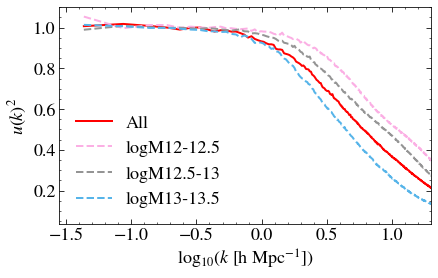

In [359]:
plt.plot(np.log10(ks_tng), uk2_all, label="All", c="red")
#plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")
plt.plot(np.log10(ks_tng), uk2_12, label="logM12-12.5", linestyle="dashed", c=palette_tab10[6])
plt.plot(np.log10(ks_tng), uk2_125, label="logM12.5-13", linestyle="dashed", c=palette_tab10[7])

plt.plot(np.log10(ks_tng), uk2_13, label="logM13-13.5", linestyle="dashed", c=palette_tab10[9])

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
#plt.plot(logks, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$u(k)^2$")
plt.xlabel(r"$\log_{10}(k\ [\mathrm{h\ Mpc^{-1}}])$")
plt.xlim(-1.55,1.3)
#plt.ylim(0,1)
plt.legend()
#plt.savefig("../figures/u_k_squared.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/cosma/local/Python/3.10.1/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


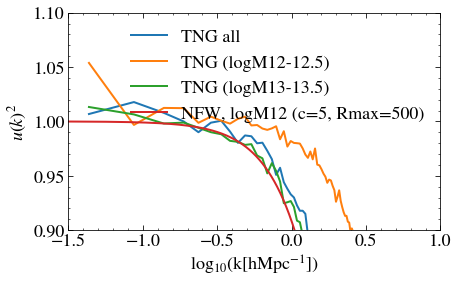

In [335]:
plt.plot(np.log10(ks_tng), uk2_all, label="TNG all")
#plt.plot(np.log10(ks_tng), uk2_11, label="TNG (logM11-11.1)")
plt.plot(np.log10(ks_tng), uk2_12, label="TNG (logM12-12.5)")
plt.plot(np.log10(ks_tng), uk2_13, label="TNG (logM13-13.5)")

#plt.plot(logks, ftc5, label="c=5")
#plt.plot(logks, ftc4, label="c=4")
#plt.plot(logks, ftc5, label=f"NFW, logM11 (c=5, Rmax=118)")
#plt.plot(logks, ft12, label=f"NFW, logM12 (c=4, Rmax=250)")
plt.plot(logks, uk1, label=f"NFW, logM12 (c=5, Rmax=500)")
#plt.plot(logks, uk2, label=f"NFW, logM12 (c=5, Rmax=500)")

#plt.plot(logks, ft13, label=f"NFW, logM13 (c=3.5, Rmax=550)")
plt.ylabel("$u(k)^2$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc^{-1}])$")
plt.xlim(-1.5,1)
plt.ylim(0.9,1.1)
plt.legend()

### Try fitting

In [ ]:
p_nfw = profile_nfw.NFWProfile(rhos=rho0_pkpc, rs=rs_pkpc)

In [ ]:
pop_fit1, pcov1 = curve_fit(profile_nfw.NFWProfile, np.log10(Pk110["k"][0:80]),ratio2[0:80],maxfev = 4000, sigma=None)
